# Graph for Loss as Initialization of function of V and n_heads & emb_dim

In [19]:
#import libraries
import os
import sys
import time
import copy

import numpy as np
import math
import random
import matplotlib.pyplot as plt

import functools
import argparse

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils

import pickle

import datasets, models
import importlib
importlib.reload(models)
import init, measures
importlib.reload(init)
importlib.reload(measures)

<module 'measures' from '/Users/julialand/Desktop/SISSA/RLM/RLM_clean/measures.py'>

In [20]:
#Parameters to change 
vocabulary = 64
n_heads = 1
emb_dim= 128
b = 0.8

In [21]:
#Creating the dataclass and defining the hyperparameters
from dataclasses import dataclass
@dataclass
class config:

    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

    dataset = 'rlm'
    mode = 'last'
    num_features = vocabulary
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = b
    train_size = 2**16 
    batch_size = 128
    accumulation = 1
    test_size = 2**15 
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    embedding_dim = emb_dim
    num_heads = n_heads
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = False
    loss_threshold = 1e-3
config.num_data = config.train_size + config.test_size
#config.num_data = config.num_classes*config.num_synonyms**((config.tuple_size**config.num_layers-1)//(config.tuple_size-1))
config.input_size = 2**config.num_layers
config.num_batches = config.train_size//config.batch_size
config.max_iters = config.max_epochs*config.num_batches

print(config.device)

print(f"Training for {config.max_iters} steps")

mps
Training for 5120 steps


In [22]:
# reinitialise dataset seeds for multiple runs
config.seed_rules = random.randint(10000000,99999999)
config.seed_sample = random.randint(10000000,99999999)
print(config.seed_rules, config.seed_sample)   

26430208 83011962


In [23]:
if config.dataset=='rlm':

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.train_size+config.test_size,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]
    entropy = rlm.entropy

print(inputs.size())
print(targets.size())
train_loader, test_loader = init.init_data(inputs, targets, config)


torch.Size([98304, 2])
torch.Size([98304])


In [24]:
config.num_tokens = 2**config.num_layers
config.seed_model = random.randint(10000000,99999999)

model = init.init_model(config)
model0 = copy.deepcopy( model)

# parameters: 214208


In [25]:
criterion, optimizer, scheduler = init.init_training(model, config)

In [26]:
%%time
dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)
print(dynamics[0])
print(dynamics[0]["testloss"])


{'t': 0, 'testloss': 4.307555476203561, 'testacc': 0.01483154296875}
4.307555476203561
CPU times: user 324 ms, sys: 95.3 ms, total: 419 ms
Wall time: 589 ms


In [7]:
#vocabulary = [64, 128, 256, 1024, 2048, 4096]
vocabulary = [8, 16, 32, 64]
tloss =[]

In [8]:
for i in vocabulary:
    vocabulary = i
    n_heads = 2
    emb_dim= 2
    b = 0.8
    from dataclasses import dataclass
    @dataclass
    class config:

        device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

        dataset = 'rlm'
        mode = 'last'
        num_features = vocabulary
        num_layers = 1
        seed_rules = 12345678
        num_tokens = 2**num_layers
        beta = b
        train_size = 2**16 
        batch_size = 128
        accumulation = 1
        test_size = 2**15 
        seed_sample = 56781234
        input_format = 'long'
        whitening = 0
        model = 'transformer_mlm'
        depth = 1
        embedding_dim = emb_dim
        num_heads = n_heads
        ffwd_size = 4
        dropout = 0
        seed_model = 12345678
        optim = 'adam'
        lr = 1e-3
        momentum = 0.0
        scheduler = 'cosine-warmup'
        warmup_time = 8
        decay_time = 2**18
        max_epochs = 10
        print_freq = 32768
        save_freq = 2
        measure_train = True
        loss_threshold = 1e-3
    config.num_data = config.train_size + config.test_size
    #config.num_data = config.num_classes*config.num_synonyms**((config.tuple_size**config.num_layers-1)//(config.tuple_size-1))
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size//config.batch_size
    config.max_iters = config.max_epochs*config.num_batches
    if config.dataset=='rlm':

        rlm = datasets.RLM(
            v=config.num_features,
            L=config.num_layers,
            beta=config.beta,
            seed_rules=config.seed_rules,
            seed_samples=config.seed_sample,
            num_data=config.train_size+config.test_size,
            probs=None,
            transform=None
        )
        inputs = rlm.trees[config.num_layers]
        targets = rlm.trees[0]
        #entropy = rlm.entropy

    train_loader, test_loader = init.init_data(inputs, targets, config)
    config.num_tokens = 2**config.num_layers
    config.seed_model = random.randint(10000000,99999999)

    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)
    print(dynamics[0]["testloss"])
    tloss.append(dynamics[0]["testloss"])


        

# parameters: 106
2.1993081495165825
# parameters: 146
3.0414393320679665
# parameters: 226
3.718278333544731
# parameters: 386
4.355150118470192


# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 50760
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51018
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51276
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51534
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 51792
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52050
# parameters: 52308
# parameters: 52308


Text(0, 0.5, 'test loss')

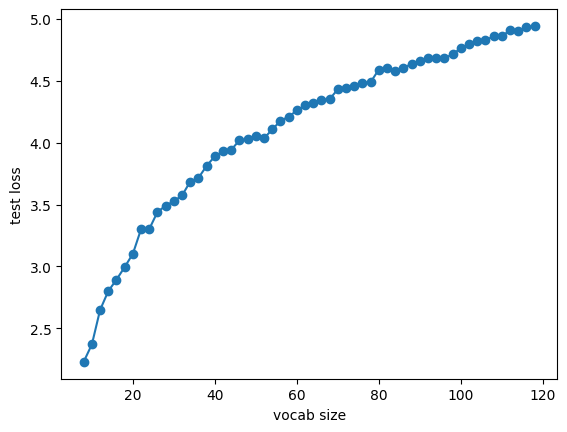

In [ ]:
vocabulary_list = list(range(8, 120, 2))
n_runs = 8

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = None
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    embedding_dim = 64
    num_heads = 1
    ffwd_size = 64
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

all_losses = []

for v in vocabulary_list:
    losses_v = []
    for _ in range(n_runs):
        config = Config()
        config.num_features = v
        config.num_data = config.train_size + config.test_size
        config.input_size = 2**config.num_layers
        config.num_batches = config.train_size // config.batch_size
        config.max_iters = config.max_epochs * config.num_batches
        config.seed_model = random.randint(10_000_000, 99_999_999)

        rlm = datasets.RLM(
            v=config.num_features,
            L=config.num_layers,
            beta=config.beta,
            seed_rules=config.seed_rules,
            seed_samples=config.seed_sample,
            num_data=config.num_data,
            probs=None,
            transform=None
        )
        inputs = rlm.trees[config.num_layers]
        targets = rlm.trees[0]

        train_loader, test_loader = init.init_data(inputs, targets, config)
        model = init.init_model(config)
        criterion, optimizer, scheduler = init.init_training(model, config)
        dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

        losses_v.append(dynamics[0]["testloss"])
    all_losses.append(losses_v)

all_losses = np.array(all_losses)          # shape: (len(vocabulary_list), n_runs)
mean_loss = all_losses.mean(axis=1)
std_loss = all_losses.std(axis=1)

plt.figure()
plt.plot(vocabulary_list, mean_loss, marker='o')
plt.fill_between(vocabulary_list, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)
plt.xlabel('vocab size')
plt.ylabel('test loss')



In [16]:
logv = []

In [17]:
logv = [math.log(v) for v in vocabulary_list]

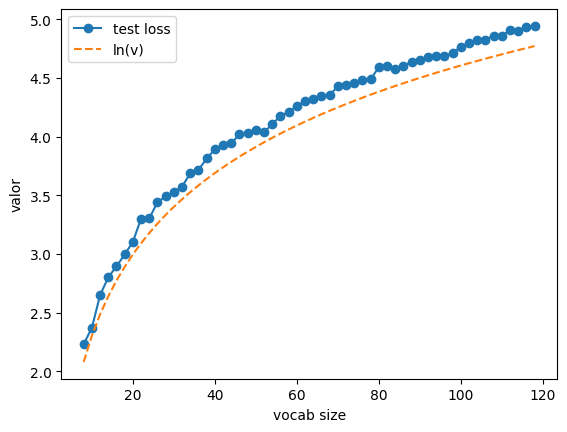

In [19]:
plt.figure()
plt.plot(vocabulary_list, mean_loss, marker='o', label='test loss')
plt.fill_between(vocabulary_list, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)
plt.plot(vocabulary_list, logv, linestyle='--', label='ln(v)')
plt.xlabel('vocab size')
plt.ylabel('valor')
plt.legend()


In [20]:
import random, torch
from dataclasses import dataclass

pairs = [(32,1), (32,2), (32,4), (32,8), (32,16), (32,32)]
tloss = []
embs = []
heads = []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])


# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736


# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400
# parameters: 854400


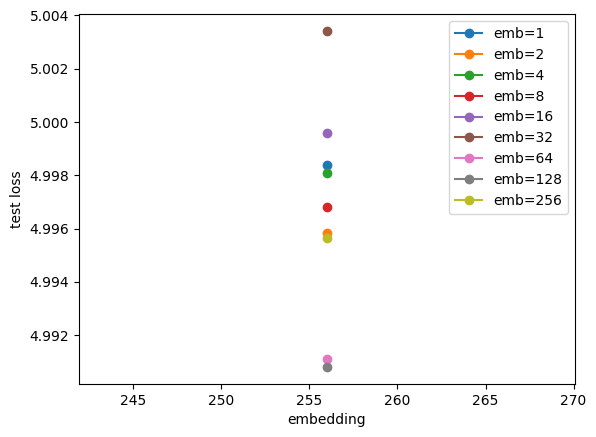

In [ ]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

emb = 256
pairs = [(emb,1), (emb,2), (emb,4), (emb,8), (emb,16), (emb,32), (emb,64), (emb, 128), (emb,256)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 128
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(embs, heads,tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'emb={e}')
plt.xlabel('num_heads')
plt.ylabel('test loss')
plt.legend()


# parameters: 66240
# parameters: 230656
# parameters: 854400
# parameters: 3281536


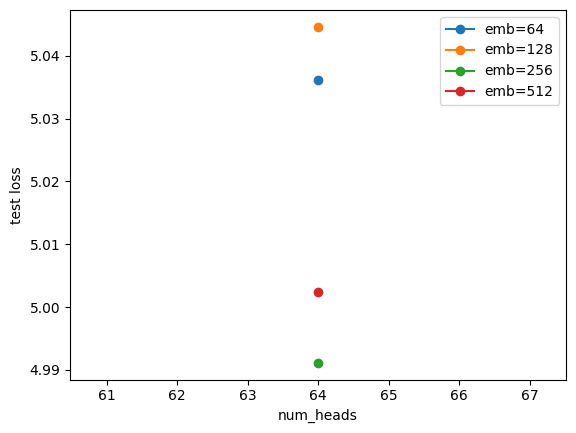

In [32]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass


num_heads = 64
pairs = [ (64,num_heads), (128,num_heads), (256,num_heads), (512,num_heads)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 128
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(embs, heads, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'emb={e}')
plt.xlabel('num_heads')
plt.ylabel('test loss')
plt.legend()

# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736
# parameters: 16736


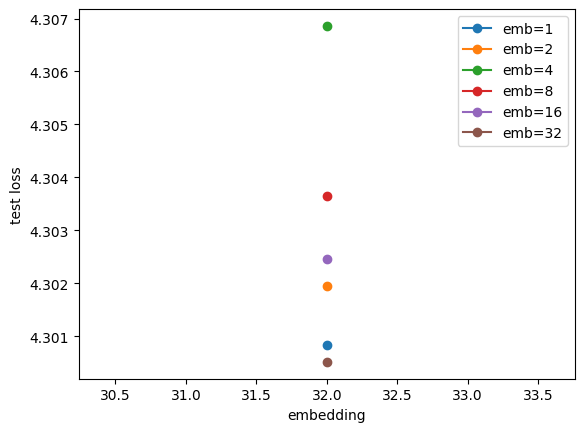

In [35]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

pairs = [(32,1), (32,2), (32,4), (32,8), (32,16), (32,32)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'emb={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()


# parameters: 214208
# parameters: 214208
# parameters: 214208
# parameters: 214208
# parameters: 214208
# parameters: 214208
# parameters: 214208
# parameters: 214208


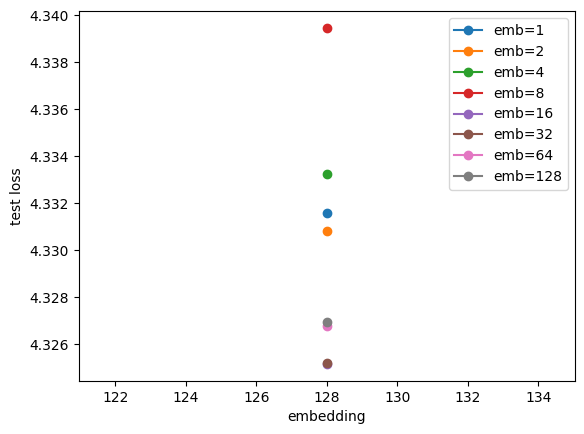

In [ ]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

emb_dim = 128

pairs = [(emb_dim,1), (emb_dim,2), (emb_dim,4), (emb_dim,8), (emb_dim,16), (emb_dim,32),(emb_dim,64),(emb_dim,128)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'emb={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()


# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568


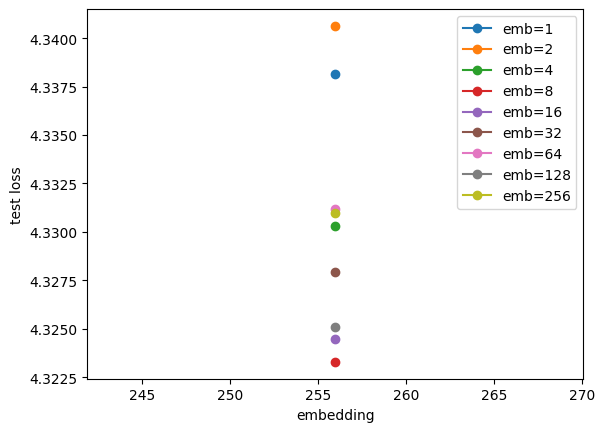

In [38]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

emb_dim = 256

pairs = [(emb_dim,1), (emb_dim,2), (emb_dim,4), (emb_dim,8), (emb_dim,16), (emb_dim,32),(emb_dim,64),(emb_dim,128), (emb_dim,256)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'emb={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()

# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568
# parameters: 821568


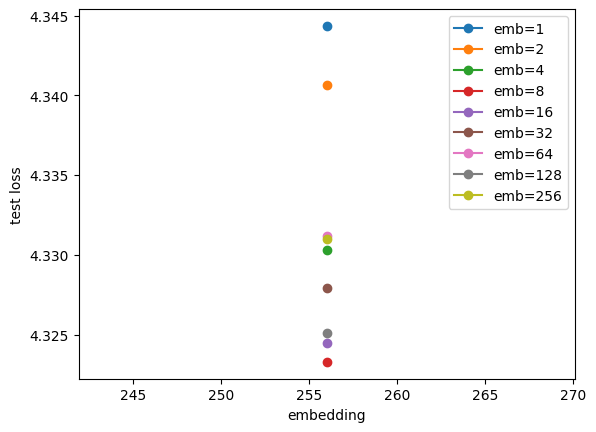

In [ ]:
import random
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass

emb_dim = 256

pairs = [(emb_dim,1), (emb_dim,2), (emb_dim,4), (emb_dim,8), (emb_dim,16), (emb_dim,32),(emb_dim,64),(emb_dim,128), (emb_dim,256)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'num_heads={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()


# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936
# parameters: 3215936


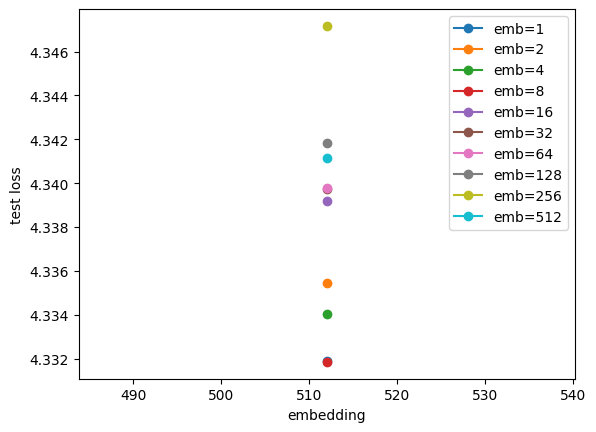

In [ ]:


emb_dim = 512

pairs = [(emb_dim,1), (emb_dim,2), (emb_dim,4), (emb_dim,8), (emb_dim,16), (emb_dim,32),(emb_dim,64),(emb_dim,128), (emb_dim,256), (emb_dim,512)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'num_heads={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()

# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264
# parameters: 12723264


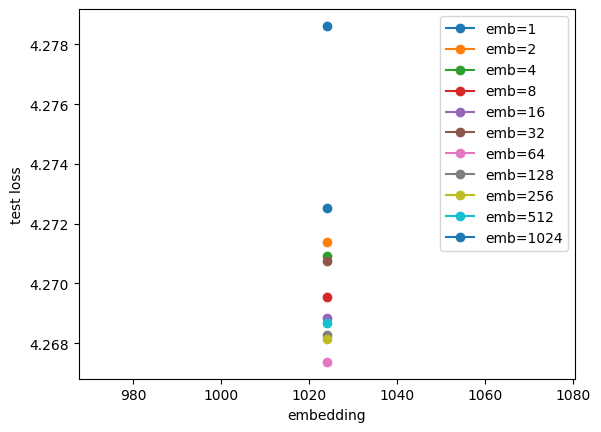

In [ ]:


emb_dim = 1024

pairs = [(emb_dim,1), (emb_dim,2), (emb_dim,4), (emb_dim,8), (emb_dim,16), (emb_dim,32),(emb_dim,64),(emb_dim,128), (emb_dim,256), (emb_dim,512), (emb_dim,1024)]
embs, heads, tloss = [], [], []

@dataclass
class Config:
    device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
    dataset = 'rlm'
    mode = 'last'
    num_features = 64
    num_layers = 1
    seed_rules = 12345678
    num_tokens = 2**num_layers
    beta = 0.8
    train_size = 2**16
    batch_size = 128
    accumulation = 1
    test_size = 2**15
    seed_sample = 56781234
    input_format = 'long'
    whitening = 0
    model = 'transformer_mlm'
    depth = 1
    ffwd_size = 4
    dropout = 0
    seed_model = 12345678
    optim = 'adam'
    lr = 1e-3
    momentum = 0.0
    scheduler = 'cosine-warmup'
    warmup_time = 8
    decay_time = 2**18
    max_epochs = 10
    print_freq = 32768
    save_freq = 2
    measure_train = True
    loss_threshold = 1e-3

for emb_dim, nh in pairs:
    config = Config()
    config.embedding_dim = emb_dim
    config.num_heads = nh
    config.num_data = config.train_size + config.test_size
    config.input_size = 2**config.num_layers
    config.num_batches = config.train_size // config.batch_size
    config.max_iters = config.max_epochs * config.num_batches
    config.seed_model = random.randint(10_000_000, 99_999_999)

    rlm = datasets.RLM(
        v=config.num_features,
        L=config.num_layers,
        beta=config.beta,
        seed_rules=config.seed_rules,
        seed_samples=config.seed_sample,
        num_data=config.num_data,
        probs=None,
        transform=None
    )
    inputs = rlm.trees[config.num_layers]
    targets = rlm.trees[0]

    train_loader, test_loader = init.init_data(inputs, targets, config)
    model = init.init_model(config)
    criterion, optimizer, scheduler = init.init_training(model, config)
    dynamics, best = init.init_output(model, criterion, train_loader, test_loader, config)

    embs.append(emb_dim)
    heads.append(nh)
    tloss.append(dynamics[0]["testloss"])

from collections import defaultdict
curvas = defaultdict(list)
for e, h, l in zip(heads, embs, tloss):
    curvas[e].append((h, l))

plt.figure()
for e, pares in curvas.items():
    pares.sort()
    hs = [p[0] for p in pares]
    ls = [p[1] for p in pares]
    plt.plot(hs, ls, marker='o', label=f'num_heads={e}')
plt.xlabel('embedding')
plt.ylabel('test loss')
plt.legend()

In [43]:
math.log(64)

4.1588830833596715